**`Installation & Chargement des packages`**

In [ ]:
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R
install.packages(c(
  "tidyverse",
  "FactoMineR",
  "factoextra",
  "cluster",
  "PCAmixdata",
  "missForest",
  "ggpubr"
))


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/tidyverse_2.0.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/FactoMineR_2.13.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/factoextra_2.0.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/cluster_2.1.8.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/PCAmixdata_3.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/missForest_1.6.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/ggpubr_0.6.3.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpUA6Mgm/downloaded_packages’


In [ ]:
%%R
install.packages("janitor")
library(janitor)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/janitor_2.2.1.tar.gz'
Content type 'application/x-gzip' length 232988 bytes (227 KB)
downloaded 227 KB


The downloaded source packages are in
	‘/tmp/RtmpUA6Mgm/downloaded_packages’


In [ ]:
%%R
library(tidyverse)
library(FactoMineR)
library(factoextra)
library(cluster)
library(PCAmixdata)
library(missForest)
library(ggpubr)
library(janitor)
library(tidyr)


**`2. Importation des données Chlordécone`**

In [ ]:
%%R
data <- read.delim(
  "BaseCLD.csv",
  sep = ";",
  dec = ",",
  header = TRUE,
  stringsAsFactors = FALSE,
  check.names = FALSE
)



In [ ]:
%%R
glimpse(data)


Rows: 31,126
Columns: 27
$ ID                    <int> 20143, 20143, 20143, 20143, 20143, 20143, 20143,…
$ ANNEE                 <int> 2010, 2010, 2010, 2010, 2010, 2010, 2010, 2010, …
$ COMMU_LAB             <chr> "GROS-MORNE", "GROS-MORNE", "GROS-MORNE", "GROS-…
$ RAIN                  <chr> "2000-3000", "2000-3000", "2000-3000", "2000-300…
$ Sol_simple            <chr> "Andosol", "Andosol", "Andosol", "Andosol", "And…
$ type_sol              <chr> "Intergrades Sols … allophane relativement ‚volu…
$ Date_prelevement      <chr> "24/05/2007", "24/05/2007", "24/05/2007", "24/05…
$ Date_enregistrement   <chr> "24/05/2007", "24/05/2007", "24/05/2007", "24/05…
$ Date_analyse          <chr> "24/05/2007", "24/05/2007", "24/05/2007", "24/05…
$ Operateur_chld        <chr> "=", "=", "=", "=", "=", "=", "=", "<", "<", "<"…
$ Taux_Chlordecone      <chr> "4.6", "4.6", "4.6", "4.6", "4.6", "4.6", "4.6",…
$ Operateur_5b          <chr> "=", "=", "=", "=", "=", "=", "=", "<", "=", "="…
$ Taux_5b_hydro

**`3. Nettoyage & Préparation`**

**3.1 Normalisation des noms + gestion des doublons**

In [ ]:
%%R
data <- data %>%
  janitor::clean_names() %>%
  distinct()

names(data)


 [1] "id"                     "annee"                  "commu_lab"             
 [4] "rain"                   "sol_simple"             "type_sol"              
 [7] "date_prelevement"       "date_enregistrement"    "date_analyse"          
[10] "operateur_chld"         "taux_chlordecone"       "operateur_5b"          
[13] "taux_5b_hydro"          "histo_banane_1970"      "histo_banane_leg_1970" 
[16] "histo_banane_1980"      "histo_banane_1992"      "histo_banane_leg_1992" 
[19] "histo_banane_histo_ban" "mnt_tpi_mean"           "mnt_tri_mean"          
[22] "mnt_rugosite_mean"      "mnt_ombrage_mean"       "mnt_exposition_mean"   
[25] "mnt_pente_mean"         "x"                      "y"                     


**3.2 Conversion des dates**

In [ ]:
%%R
data <- data %>%
  mutate(across(contains("date"),
                ~ as.Date(., format = "%d/%m/%Y")))



**3.3 Conversion des variables numériques**

In [ ]:
%%R
num_cols <- data %>%
  select(where(is.numeric)) %>%
  names()

num_cols


[1] "id"                     "annee"                  "histo_banane_1970"     
[4] "histo_banane_1980"      "histo_banane_1992"      "histo_banane_histo_ban"


In [ ]:
%%R
data[num_cols] <- lapply(data[num_cols], function(x) {
  as.numeric(gsub(",", ".", as.character(x)))
})


**`4. Analyse des valeurs manquantes Imputation par forêt aléatoire (méthode robuste)`**

In [ ]:
%%R
data_mf <- data %>%
  mutate(
    across(where(is.Date), as.numeric),
    across(where(is.character), as.factor)
  )

data_imputed <- missForest(data_mf)$ximp



**`5. Détection des valeurs aberrantes`**

**Boxplots multivariés**

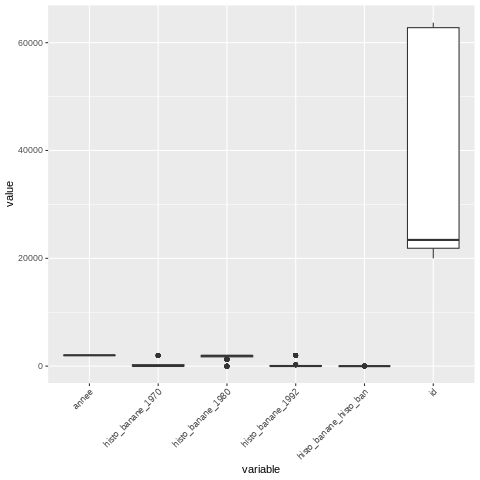

In [ ]:
%%R
data_imputed %>%
  select(all_of(num_cols)) %>%
  pivot_longer(cols = everything(),
               names_to = "variable",
               values_to = "value") %>%
  ggplot(aes(variable, value)) +
  geom_boxplot() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))



**Distance de Mahalanobis**

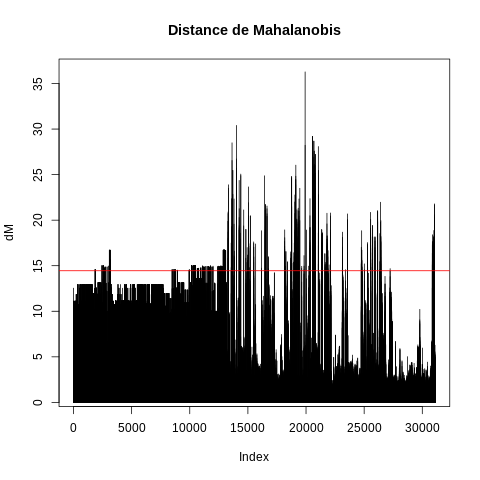

In [ ]:
%%R
X <- data_imputed %>% select(all_of(num_cols))

covX   <- cov(X)
center <- colMeans(X)
dM     <- mahalanobis(X, center, covX)

plot(dM, type = "h", main = "Distance de Mahalanobis")
abline(h = qchisq(0.975, df = ncol(X)), col = "red")


**`6. ACP – Analyse en Composantes Principales`**

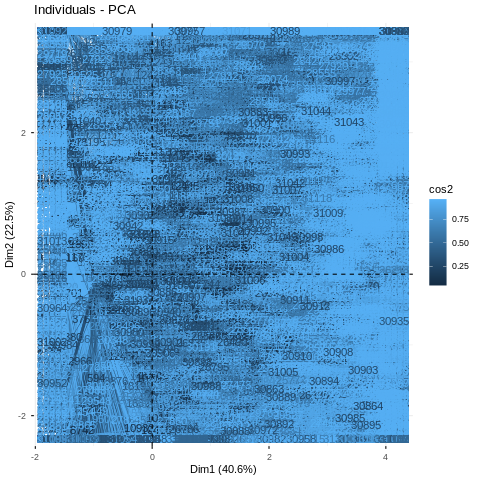

In [ ]:
%%R
acp <- PCA(data_imputed[, num_cols], scale.unit = TRUE, graph = FALSE)

fviz_eig(acp)
fviz_pca_var(acp, col.var = "contrib")
fviz_pca_ind(acp, col.ind = "cos2", repel = TRUE)


**`7. AFDM – Analyse Factorielle de Données Mixtes`**

In [ ]:
%%R
quanti <- data_imputed %>% select(all_of(num_cols))
quali  <- data_imputed %>% select(where(is.factor))

afdm <- FAMD(cbind(quanti, quali), ncp = 5, graph = FALSE)

fviz_famd_ind(afdm, repel = TRUE)
fviz_famd_var(afdm, repel = TRUE)


UsageError: Cell magic `%%R` not found.


**`8. Distances (Euclidienne, Manhattan, Canberra, Minkowski)`**

In [ ]:
%%R
dist_euc  <- dist(quanti, method = "euclidean")
dist_man  <- dist(quanti, method = "manhattan")
dist_can  <- dist(quanti, method = "canberra")
dist_mink <- dist(quanti, method = "minkowski", p = 3)


UsageError: Cell magic `%%R` not found.


**`9. CAH – Classification Ascendante Hiérarchique`**

**9.1 CAH Ward**

In [ ]:
%%R
cah <- hclust(dist_euc, method="ward.D2")
plot(cah, main="Dendrogramme CAH – Ward")


**9.2 Découpage en k groupes**

In [ ]:
%%R
fviz_nbclust(quanti, kmeans, method = "wss")

km <- kmeans(quanti, centers = 4, nstart = 25)
fviz_cluster(km, data = quanti)


In [ ]:
%%R
groups_cah <- cutree(cah, k=4)
table(groups_cah)


**`10. K-means clustering`**

**10.1 Choix du nombre optimal (méthode du coude)**

In [ ]:
%%R
fviz_nbclust(quanti, kmeans, method="wss")


In [ ]:
%%R
km <- kmeans(quanti, centers=4, nstart=25)
fviz_cluster(km, data=quanti)


**`11. Test de Kolmogorov-Smirnov`**

In [ ]:
%%R
ks.test(data_imputed$taux_chlordecone, "pnorm",
        mean(data_imputed$taux_chlordecone),
        sd(data_imputed$taux_chlordecone))


**`12. Droite de Henry (QQ-plot)`**

In [ ]:
%%R
ggqqplot(data_imputed$taux_chlordecone)


**`13. Analyse spatiale simple (si coordonnées X/Y)`**

**Carte des points**

In [ ]:
%%R
ggplot(data_imputed, aes(x=x, y=y, color=taux_chlordecone)) +
  geom_point(size=3) +
  scale_color_viridis_c() +
  coord_equal() +
  theme_minimal()


**`14. Pipeline final d’analyse – Chlordécone`**

**Modèle explicatif : PCA + clustering + spatial**

In [ ]:
%%R
model_data <- data.frame(
  PC1 = acp$ind$coord[,1],
  PC2 = acp$ind$coord[,2],
  cluster = km$cluster,
  taux = data_imputed$taux_chlordecone,
  x = data_imputed$x,
  y = data_imputed$y
)


In [ ]:
%%R
ggplot(model_data, aes(PC1, PC2, color=taux, shape=factor(cluster))) +
  geom_point(size=3) +
  scale_color_viridis_c() +
  theme_minimal()


**`15. Export des résultats`**

In [ ]:
%%R
write.csv(model_data, "resultats_chlordecone.csv", row.names=FALSE)
